# Bilayer

**Note:** due to the basis chosen here, there are some unphysical low-energy Landau levels! We should have 2 low-energy states per valley and spin, but in fact, below you will find 3 plus 1 strange LL at positive energies (due do layer-hybridization of unphysical single-layer LL).

This is due to the truncation of the ladder operator basis. 

This can be avoided through a more careful choice of the Landau level basis of the individual graphene layer blocks, or we can discard all eigensolution that have nearly all their weights near the Landau level trunction.

/Users/wolft/jetstream_clone/contimod_repos/contimod_repos/contimod_graphene/src/contimod_graphene/rhombohedral.py:155: SyntaxWarning: invalid escape sequence '\d'
  """


(-15.0, 15.0)

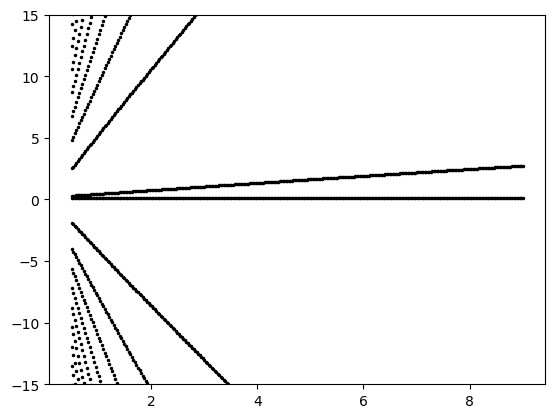

In [1]:
import contimod as cm
import contimod_graphene as cmg 

import jax 
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt


params = cmg.params.graphene_params_BLG
params["U"] = 0.0
h_func = cmg.rhombohedral.get_hamiltonian_LL(N_layers=2, Ncut=50, params=params)

Bs = jnp.linspace(0.5, 9, 300)

eigvals = []
for B in Bs:
    h = h_func(B)
    e, v = jnp.linalg.eigh(h)
    eigvals.append(e)

for xe, ye in zip(Bs, eigvals):
    plt.plot([xe] * len(ye), ye, "k.", ms=3)
    
plt.gca().set_ylim(-15, 15)

# 4-layer

(-5.0, 8.0)

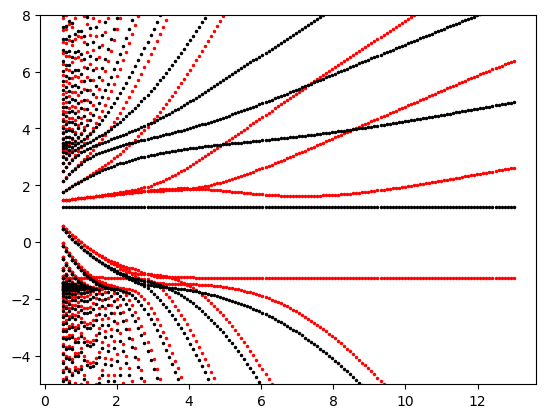

In [2]:
import contimod as cm
import contimod_graphene as cmg 

import jax 
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import copy


params = cmg.params.graphene_params_TLG
params["U"] = 2.5
h_func = cmg.rhombohedral.get_hamiltonian_LL(N_layers=4, Ncut=75, params=params)
h_func_kp = cmg.rhombohedral.get_hamiltonian_LL(N_layers=4, Ncut=75, flip_valley=True, params=params)

Bs = jnp.linspace(0.5, 13, 150)

eigvals = []
eigvals_kp = []
for B in Bs:
    hK = h_func(B)
    e, v = jnp.linalg.eigh(hK)
    eigvals.append(e)
    hKp = h_func_kp(B)
    e, v = jnp.linalg.eigh(hKp)
    eigvals_kp.append(e)

for xe, ye in zip(Bs, eigvals):
    plt.plot([xe] * len(ye), ye, "r.", ms=3)
for xe, ye in zip(Bs, eigvals_kp): 
    plt.plot([xe] * len(ye), ye, "k.", ms=3)

plt.gca().set_ylim(-5, 8)